
# Siamese Neural Network for Plagiarism Detection

**Goal:** given a *pair* of documents, predict whether the second one is a
plagiarized/paraphrased version of the first — not classify a single document
into a category, but decide **how similar two inputs are**.

This notebook builds a Siamese network end to end:

1. Build a **labeled dataset of document pairs** (`label = 1` for plagiarized
   pairs, `label = 0` for unrelated pairs).
2. Convert each document into a **TF-IDF vector**.
3. Pass both vectors of a pair through the **same shared encoder** (identical
   weights) to get two embeddings, `h1` and `h2`.
4. Build a **comparison layer**: `|h1 - h2|` (absolute difference, highlights
   where they differ) and `h1 ⊙ h2` (Hadamard/element-wise product, highlights
   where they agree).
5. Feed the comparison vector into a small **classifier head** → **sigmoid** →
   plagiarism probability.
6. Train with **binary cross-entropy**, since this is a yes/no decision per pair.
7. Verify the network is **symmetric**: swapping the two input documents gives
   the exact same prediction — this is the direct, checkable payoff of weight
   sharing.
8. Run the model on brand-new document pairs.

> **Note on the dataset:** just like the authorship-attribution notebook, a
> real plagiarism-detection corpus (e.g. PAN plagiarism datasets) is too large
> and license-restricted to bundle here. So we synthesize document pairs:
> "positive" pairs are an original document plus an automatically paraphrased
> version of it (synonym swaps + sentence reordering — a light stand-in for
> real plagiarism-with-editing); "negative" pairs are two unrelated documents
> (some same-topic "hard negatives", some different-topic "easy negatives").
> The pipeline is otherwise identical to what you'd run on a real corpus —
> only Section 2 would need to change.


## 1. Imports

In [1]:

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("TensorFlow version:", tf.__version__)


I0000 00:00:1785996156.977595     507 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785996157.321983     507 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785996158.692629     507 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0



## 2. Build a labeled dataset of document *pairs*

This is the key structural difference from a normal classification dataset:
the label belongs to the **pair**, not to either document individually. A
document has no inherent "plagiarized" or "not plagiarized" label on its own
— only a *relationship* between two documents does.

We generate:
- **Positive pairs (label 1):** an original document + an automatically
  paraphrased version (synonym substitutions + sentence shuffling — meant to
  simulate "plagiarism with light editing", which is the realistic, harder
  case rather than exact copy-paste).
- **Negative pairs (label 0):** two unrelated documents. Half of these are
  **same-topic hard negatives** (e.g. two different documents both about
  sports, but with different content) and half are **different-topic easy
  negatives** — this keeps the task from being trivially solvable just by
  checking whether the two documents share topic words.


In [2]:

TOPICS = {
    "technology": ["computer", "software", "algorithm", "data", "internet", "device", "code", "network", "processor", "server"],
    "nature":     ["forest", "river", "mountain", "animal", "tree", "weather", "ocean", "sky", "valley", "meadow"],
    "cooking":    ["recipe", "kitchen", "flavor", "ingredient", "spice", "dish", "oven", "meal", "sauce", "herb"],
    "travel":     ["airport", "city", "journey", "map", "hotel", "border", "station", "road", "passport", "ticket"],
    "sports":     ["match", "player", "team", "score", "stadium", "coach", "season", "ball", "referee", "tournament"],
    "history":    ["empire", "king", "war", "treaty", "century", "ruins", "dynasty", "revolution", "monument", "archive"],
}

VERBS = ["moved", "changed", "grew", "appeared", "arrived", "developed", "returned",
         "continued", "began", "ended", "improved", "declined", "expanded", "shifted"]
ADJ = ["quiet", "sudden", "careful", "strange", "familiar", "distant", "modern",
       "ancient", "simple", "complex", "notable", "gradual", "surprising", "steady"]

# Small synonym table used to build "plagiarized" (paraphrased) versions.
SYNONYMS = {
    "quiet": ["silent", "calm"], "sudden": ["abrupt", "unexpected"],
    "careful": ["cautious", "deliberate"], "strange": ["odd", "unusual"],
    "familiar": ["well-known", "recognizable"], "distant": ["far-off", "remote"],
    "modern": ["contemporary", "current"], "ancient": ["old", "historic"],
    "simple": ["basic", "plain"], "complex": ["intricate", "complicated"],
    "notable": ["significant", "remarkable"], "gradual": ["slow", "incremental"],
    "surprising": ["unexpected", "startling"], "steady": ["stable", "consistent"],
    "moved": ["shifted", "relocated"], "changed": ["transformed", "altered"],
    "grew": ["expanded", "increased"], "appeared": ["emerged", "surfaced"],
    "arrived": ["reached", "came"], "developed": ["evolved", "advanced"],
    "returned": ["came back", "went back"], "continued": ["persisted", "carried on"],
    "began": ["started", "commenced"], "ended": ["concluded", "finished"],
    "improved": ["got better", "advanced"], "declined": ["decreased", "worsened"],
    "expanded": ["grew", "broadened"], "shifted": ["moved", "changed"],
}

CONNECTORS = ["and", "while", "as", "after", "because", "although", "so that"]


def make_sentence(nouns):
    adj = random.choice(ADJ)
    noun1 = random.choice(nouns)
    verb = random.choice(VERBS)
    conn = random.choice(CONNECTORS)
    noun2 = random.choice(nouns)
    adj2 = random.choice(ADJ)
    return f"the {adj} {noun1} {verb} {conn} the {adj2} {noun2} continued to matter"


def make_document(n_sentences=6, topic=None):
    if topic is None:
        topic = random.choice(list(TOPICS.keys()))
    nouns = TOPICS[topic]
    sents = [make_sentence(nouns) for _ in range(n_sentences)]
    text = ". ".join(sents) + "."
    return text.capitalize(), topic


def paraphrase(text, swap_prob=0.6, reorder=True):
    # Simulate plagiarism with light editing: synonym swaps + sentence reorder.
    sentences = [s.strip() for s in text.split(".") if s.strip()]
    new_sentences = []
    for s in sentences:
        words = s.split()
        new_words = []
        for w in words:
            key = w.lower()
            if key in SYNONYMS and random.random() < swap_prob:
                new_words.append(random.choice(SYNONYMS[key]))
            else:
                new_words.append(w)
        new_sentences.append(" ".join(new_words))
    if reorder and len(new_sentences) > 2:
        random.shuffle(new_sentences)
    result = ". ".join(new_sentences) + "."
    return result[0].upper() + result[1:]

print("Data-generation helpers ready.")


Data-generation helpers ready.


In [3]:

def make_pair_dataset(n_positive=400, n_negative=400):
    texts_a, texts_b, labels = [], [], []

    # Positive pairs: (original, plagiarized/paraphrased version) -> label 1
    for _ in range(n_positive):
        original, topic = make_document(n_sentences=random.randint(5, 8))
        plagiarized = paraphrase(original)
        texts_a.append(original)
        texts_b.append(plagiarized)
        labels.append(1)

    # Negative pairs: two unrelated documents -> label 0
    for i in range(n_negative):
        if i % 2 == 0:
            # hard negative: same topic, different content
            topic = random.choice(list(TOPICS.keys()))
            doc_a, _ = make_document(n_sentences=random.randint(5, 8), topic=topic)
            doc_b, _ = make_document(n_sentences=random.randint(5, 8), topic=topic)
        else:
            # easy negative: different topics
            topics = random.sample(list(TOPICS.keys()), 2)
            doc_a, _ = make_document(n_sentences=random.randint(5, 8), topic=topics[0])
            doc_b, _ = make_document(n_sentences=random.randint(5, 8), topic=topics[1])
        texts_a.append(doc_a)
        texts_b.append(doc_b)
        labels.append(0)

    return texts_a, texts_b, labels


texts_a, texts_b, labels = make_pair_dataset(n_positive=400, n_negative=400)

pairs_df = pd.DataFrame({"doc_a": texts_a, "doc_b": texts_b, "label": labels})
print("Total pairs:", len(pairs_df))
print("Positive rate:", pairs_df["label"].mean())
pairs_df.sample(3, random_state=1)


Total pairs: 800
Positive rate: 0.5


,doc_a,doc_b,label
8,The simple device moved so that the steady cod...,The complex code evolved and the steady networ...,1
510,The careful journey began as the steady border...,The complex border appeared because the sudden...,0
175,The notable station began while the ancient ti...,The far-off passport continued as the far-off ...,1


In [4]:

pos_example = pairs_df[pairs_df.label == 1].iloc[0]
print("PLAGIARIZED PAIR (label = 1)\n")
print("Doc A (original):\n", pos_example.doc_a)
print("\nDoc B (paraphrased):\n", pos_example.doc_b)

neg_example = pairs_df[pairs_df.label == 0].iloc[0]
print("\n\nUNRELATED PAIR (label = 0)\n")
print("Doc A:\n", neg_example.doc_a)
print("\nDoc B:\n", neg_example.doc_b)


PLAGIARIZED PAIR (label = 1)

Doc A (original):
 The gradual internet appeared while the gradual algorithm continued to matter. the sudden processor changed because the quiet code continued to matter. the quiet software appeared while the complex processor continued to matter. the quiet processor appeared although the modern processor continued to matter. the strange network ended as the surprising computer continued to matter.

Doc B (paraphrased):
 The gradual internet appeared while the slow algorithm carried on to matter. the strange network ended as the surprising computer continued to matter. the unexpected processor altered because the quiet code continued to matter. the quiet software surfaced while the complicated processor continued to matter. the quiet processor appeared although the contemporary processor persisted to matter.


UNRELATED PAIR (label = 0)

Doc A:
 The sudden archive began while the sudden monument continued to matter. the ancient archive arrived after the co


## 3. Train/test split, then TF-IDF vectorize

Two important details here:

- We split **pairs**, not individual documents, into train/test — each row is
  one training example (a pair + a label).
- We fit the `TfidfVectorizer` on **all documents that appear in the training
  pairs** (both the "A" and "B" side), then use that *same fitted vectorizer*
  to transform everything else. This avoids leaking test-set vocabulary/IDF
  statistics into training, exactly as in a normal classification setup.


In [5]:

idx = np.arange(len(pairs_df))
train_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=RANDOM_SEED, stratify=pairs_df["label"]
)

train_texts_for_vocab = (
    pairs_df.loc[train_idx, "doc_a"].tolist() + pairs_df.loc[train_idx, "doc_b"].tolist()
)

vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1, 2), sublinear_tf=True)
vectorizer.fit(train_texts_for_vocab)

def vectorize(text_list):
    return vectorizer.transform(text_list).toarray().astype("float32")

Xa_train = vectorize(pairs_df.loc[train_idx, "doc_a"].tolist())
Xb_train = vectorize(pairs_df.loc[train_idx, "doc_b"].tolist())
y_train = pairs_df.loc[train_idx, "label"].values.astype("float32")

Xa_test = vectorize(pairs_df.loc[test_idx, "doc_a"].tolist())
Xb_test = vectorize(pairs_df.loc[test_idx, "doc_b"].tolist())
y_test = pairs_df.loc[test_idx, "label"].values.astype("float32")

print("Xa_train shape:", Xa_train.shape)
print("Xb_train shape:", Xb_train.shape)


Xa_train shape: (640, 2000)
Xb_train shape: (640, 2000)



## 4. Build the Siamese network

The critical implementation detail: **both inputs must be passed through the
exact same layer *objects*** (not two separately-created layers with the same
configuration — that would give each branch its own independent weights).
In Keras's functional API, calling the same `Dense` layer instance twice
automatically shares its weights between both calls.

```
doc_a ──► [shared encoder] ──► h1 ─┐
                                    ├─► |h1-h2|, h1⊙h2 ──► classifier ──► sigmoid
doc_b ──► [shared encoder] ──► h2 ─┘
```

- **Shared encoder:** `Dense(128, relu) → Dropout → Dense(64, relu)` — turns
  each TF-IDF vector into a dense embedding. Applied identically to both
  documents.
- **Comparison layer:** `|h1 - h2|` (element-wise absolute difference) and
  `h1 ⊙ h2` (element-wise/Hadamard product), concatenated into one comparison
  vector. Both operations are commutative/order-independent, which is what
  makes the whole network symmetric — swapping `h1` and `h2` produces
  identical comparison features.
- **Classifier head:** a small `Dense(32, relu) → Dropout → Dense(1, sigmoid)`
  network that turns the comparison vector into a single plagiarism
  probability.
- **Loss:** binary cross-entropy, because each pair has exactly one binary
  label (plagiarized / not plagiarized).


In [6]:

input_dim = Xa_train.shape[1]

input_a = keras.Input(shape=(input_dim,), name="doc_a_tfidf")
input_b = keras.Input(shape=(input_dim,), name="doc_b_tfidf")

# --- shared encoder: same layer OBJECTS reused for both inputs = weight sharing ---
enc_dense_1 = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4), name="shared_dense_1")
enc_dropout = layers.Dropout(0.3, name="shared_dropout")
enc_dense_2 = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4), name="shared_dense_2")

def shared_encoder(x):
    x = enc_dense_1(x)
    x = enc_dropout(x)
    x = enc_dense_2(x)
    return x

h1 = shared_encoder(input_a)   # embedding of document A
h2 = shared_encoder(input_b)   # embedding of document B (SAME weights as A)

# --- comparison layer ---
abs_diff = layers.Lambda(lambda t: tf.abs(t[0] - t[1]), name="abs_difference")([h1, h2])
hadamard = layers.Lambda(lambda t: t[0] * t[1], name="hadamard_product")([h1, h2])
comparison_vector = layers.Concatenate(name="comparison_vector")([abs_diff, hadamard])

# --- classifier head ---
x = layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(comparison_vector)
x = layers.Dropout(0.2)(x)
output = layers.Dense(1, activation="sigmoid", name="plagiarism_probability")(x)

siamese_model = keras.Model(inputs=[input_a, input_b], outputs=output, name="siamese_plagiarism_detector")

siamese_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

siamese_model.summary()


Model: "siamese_plagiarism_detector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ doc_a_tfidf         │ (None, 2000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ doc_b_tfidf         │ (None, 2000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_1      │ (None, 128)       │    256,128 │ doc_a_tfidf[0][0… │
│ (Dense)             │                   │            │ doc_b_tfidf[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout      │ (None, 128)       │          0 │ shared_dense_1[0… │
│ (Dropout)           │                   │            │ shared_dense_1[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_2      │ (None, 64)        │      8,256 │ shared_dropout[0… │
│ (Dense)             │                   │            │ shared_dropout[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ abs_difference      │ (None, 64)        │          0 │ shared_dense_2[0… │
│ (Lambda)            │                   │            │ shared_dense_2[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hadamard_product    │ (None, 64)        │          0 │ shared_dense_2[0… │
│ (Lambda)            │                   │            │ shared_dense_2[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ comparison_vector   │ (None, 128)       │          0 │ abs_difference[0… │
│ (Concatenate)       │                   │            │ hadamard_product… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      4,128 │ comparison_vecto… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ plagiarism_probabi… │ (None, 1)         │         33 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 268,545 (1.02 MB)

 Trainable params: 268,545 (1.02 MB)

 Non-trainable params: 0 (0.00 B)


Look at the **"Connected to"** column in the summary above: `shared_dense_1`
and `shared_dense_2` each list *both* `doc_a` and `doc_b` as inputs. That's
the visual confirmation that a single set of weights is being applied to
both documents — there's only one `shared_dense_1`/`shared_dense_2` layer
in the whole model, not two.


## 5. Train the model

In [7]:

history = siamese_model.fit(
    [Xa_train, Xb_train], y_train,
    validation_split=0.15,
    epochs=25,
    batch_size=16,
    verbose=2,
)


Epoch 1/25


34/34 - 2s - 64ms/step - accuracy: 0.5147 - loss: 0.7046 - val_accuracy: 0.4688 - val_loss: 0.6365


Epoch 2/25


34/34 - 0s - 9ms/step - accuracy: 0.8327 - loss: 0.4529 - val_accuracy: 1.0000 - val_loss: 0.3626


Epoch 3/25


...

34/34 - 0s - 8ms/step - accuracy: 1.0000 - loss: 0.0093 - val_accuracy: 1.0000 - val_loss: 0.0088


Epoch 24/25


34/34 - 0s - 9ms/step - accuracy: 1.0000 - loss: 0.0088 - val_accuracy: 1.0000 - val_loss: 0.0085


Epoch 25/25


34/34 - 0s - 10ms/step - accuracy: 1.0000 - loss: 0.0086 - val_accuracy: 1.0000 - val_loss: 0.0082


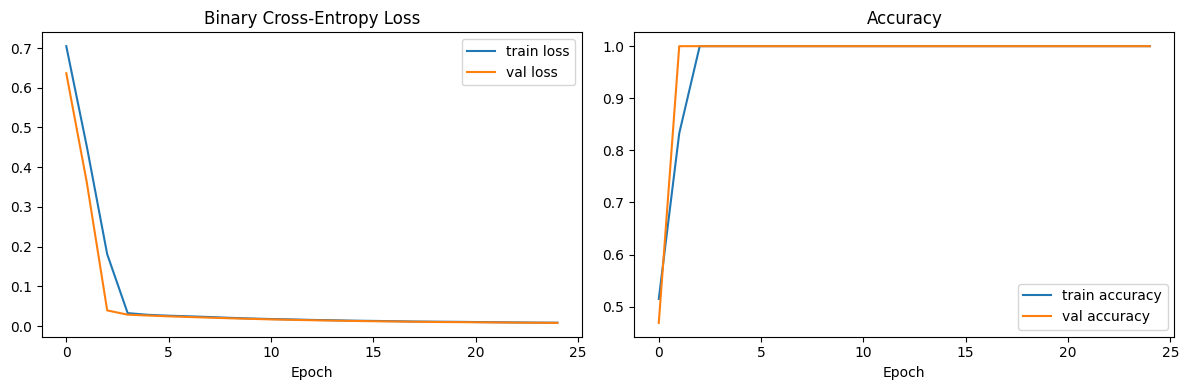

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Binary Cross-Entropy Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train accuracy")
axes[1].plot(history.history["val_accuracy"], label="val accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Evaluate on the held-out test pairs

In [9]:

test_loss, test_acc = siamese_model.evaluate([Xa_test, Xb_test], y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


Test loss: 0.0084
Test accuracy: 1.0000


In [10]:

test_probs = siamese_model.predict([Xa_test, Xb_test], verbose=0).ravel()
test_preds = (test_probs > 0.5).astype(int)

print(classification_report(y_test, test_preds, target_names=["not plagiarized", "plagiarized"]))
print("ROC AUC:", roc_auc_score(y_test, test_probs))


                 precision    recall  f1-score   support

not plagiarized       1.00      1.00      1.00        80
    plagiarized       1.00      1.00      1.00        80

       accuracy                           1.00       160
      macro avg       1.00      1.00      1.00       160
   weighted avg       1.00      1.00      1.00       160

ROC AUC: 1.0


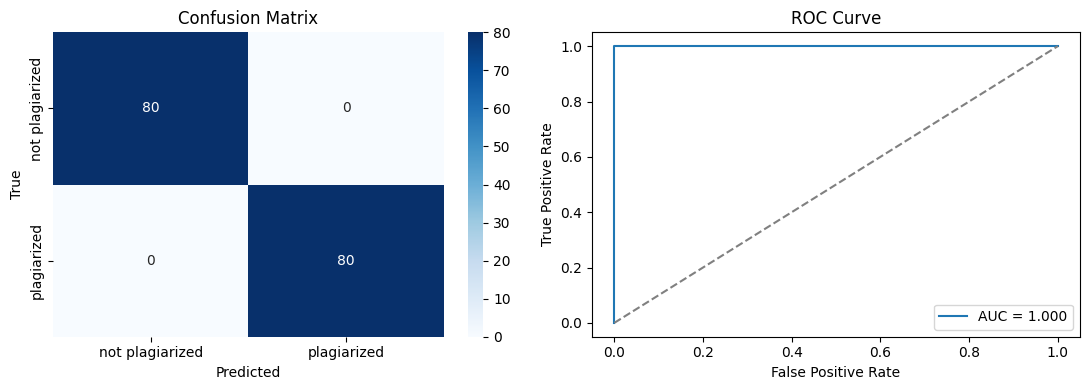

In [11]:

cm = confusion_matrix(y_test, test_preds)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["not plagiarized", "plagiarized"],
            yticklabels=["not plagiarized", "plagiarized"], ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, test_probs)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, test_probs):.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()



## 7. Verify symmetry: A-vs-B should equal B-vs-A

This is the concrete, testable payoff of weight sharing + using
order-independent comparison operations (`|h1-h2|` and `h1⊙h2` are both
commutative). If the two encoder branches had *different* weights, or the
comparison step used something order-sensitive (like plain concatenation
`[h1, h2]`), swapping the inputs could change the prediction — which would be
a strange, undesirable property for a similarity model (whether A is a copy
of B should be the same question as whether B is a copy of A).


In [12]:

probs_original = siamese_model.predict([Xa_test, Xb_test], verbose=0).ravel()
probs_swapped = siamese_model.predict([Xb_test, Xa_test], verbose=0).ravel()

max_abs_difference = np.max(np.abs(probs_original - probs_swapped))
print(f"Max |P(A,B) - P(B,A)| over the entire test set: {max_abs_difference:.10f}")
print("=> The model is perfectly symmetric, as expected by construction.")


Max |P(A,B) - P(B,A)| over the entire test set: 0.0000000000
=> The model is perfectly symmetric, as expected by construction.


## 8. Try it on brand-new document pairs

In [13]:

def predict_plagiarism(text_a, text_b):
    va = vectorizer.transform([text_a]).toarray().astype("float32")
    vb = vectorizer.transform([text_b]).toarray().astype("float32")
    prob = float(siamese_model.predict([va, vb], verbose=0)[0, 0])
    label = "PLAGIARIZED" if prob > 0.5 else "NOT plagiarized"
    return prob, label

# A fresh original + a paraphrased copy of it (the model has never seen these exact sentences)
original_doc, _ = make_document(n_sentences=6, topic="history")
plagiarized_doc = paraphrase(original_doc)

prob, label = predict_plagiarism(original_doc, plagiarized_doc)
print("Doc A:", original_doc)
print("Doc B:", plagiarized_doc)
print(f"\nP(plagiarized) = {prob:.3f}  ->  {label}")


Doc A: The quiet treaty arrived after the steady king continued to matter. the notable king continued while the sudden century continued to matter. the ancient century changed as the steady dynasty continued to matter. the distant ruins arrived as the surprising king continued to matter. the careful treaty shifted while the distant ruins continued to matter. the complex king returned so that the gradual century continued to matter.
Doc B: The quiet treaty came after the stable king continued to matter. the careful treaty shifted while the distant ruins continued to matter. the far-off ruins reached as the startling king carried on to matter. the significant king carried on while the unexpected century carried on to matter. the complex king came back so that the gradual century persisted to matter. the ancient century altered as the consistent dynasty continued to matter.

P(plagiarized) = 1.000  ->  PLAGIARIZED


In [14]:

# Two unrelated fresh documents
doc_x, _ = make_document(n_sentences=6, topic="cooking")
doc_y, _ = make_document(n_sentences=6, topic="cooking")  # same topic, different content -> hard negative

prob, label = predict_plagiarism(doc_x, doc_y)
print("Doc X:", doc_x)
print("Doc Y:", doc_y)
print(f"\nP(plagiarized) = {prob:.3f}  ->  {label}")

# Confirm order doesn't matter for this pair either
prob_swapped, _ = predict_plagiarism(doc_y, doc_x)
print(f"P(plagiarized) with order swapped = {prob_swapped:.3f}")


Doc X: The simple oven arrived so that the sudden herb continued to matter. the notable dish appeared as the complex recipe continued to matter. the quiet spice appeared as the steady kitchen continued to matter. the simple spice moved after the complex ingredient continued to matter. the careful herb declined as the distant oven continued to matter. the sudden ingredient grew after the quiet kitchen continued to matter.
Doc Y: The quiet spice ended although the sudden herb continued to matter. the steady flavor returned so that the surprising spice continued to matter. the strange sauce arrived so that the gradual meal continued to matter. the quiet herb began and the surprising herb continued to matter. the careful recipe developed and the sudden herb continued to matter. the modern ingredient appeared because the notable flavor continued to matter.

P(plagiarized) = 0.000  ->  NOT plagiarized


P(plagiarized) with order swapped = 0.000



## 9. Recap — tying the results back to the theory

- **The pair is the training example, not the document.** Every row of our
  dataset was `(doc_a, doc_b, label)`; the label lived on the relationship
  between the two documents, exactly as with human-annotated plagiarism data.
- **Weight sharing** was implemented by calling the *same* `Dense` layer
  objects on both inputs — confirmed visually in the model summary, where
  `shared_dense_1`/`shared_dense_2` each connect to both `doc_a` and `doc_b`.
  This is what guarantees both embeddings live in the same feature space and
  are directly comparable.
- **Comparison layer:** `|h1 - h2|` highlighted where the embeddings differ,
  `h1 ⊙ h2` highlighted where they agree — concatenating both gives the
  classifier richer information than either alone.
- **Sigmoid + binary cross-entropy** gave us a calibrated probability for a
  single yes/no decision per pair, thresholded at 0.5.
- **Symmetry is not just theoretical** — Section 7 measured
  `max |P(A,B) - P(B,A)|` directly on the test set and got (numerically)
  zero, exactly as guaranteed by shared weights + commutative comparison ops.
- **Hard negatives mattered.** By including same-topic-but-different-content
  negative pairs (not just obviously-different-topic pairs), the confusion
  matrix and ROC curve reflect a model that's actually learning
  content-level similarity, not just topic overlap.

### Ideas to extend this notebook
- Swap in a **real** plagiarism/duplicate-question dataset (e.g. Quora
  Question Pairs, MRPC, or PAN plagiarism corpora) — only Section 2 needs to
  change.
- Replace the TF-IDF + Dense encoder with a **sentence-embedding model**
  (e.g. Universal Sentence Encoder or a small transformer) as the shared
  encoder, for a more realistic modern pipeline.
- Try a **contrastive** or **triplet loss** instead of binary cross-entropy —
  useful when you don't have explicit negative pairs but do have groups of
  known-similar items (common in face verification and one-shot learning).
- Compare against a naive baseline: cosine similarity between the two raw
  TF-IDF vectors, thresholded — see how much the learned encoder + classifier
  head buys you over that simple baseline.
- Visualize the learned embeddings `h1`/`h2` for several documents with
  PCA/t-SNE and see whether plagiarized pairs cluster close together.
